## Loading data products

- Load remote data for desired moorings
- Write data locally

Using https://github.com/diodon/QIMOS/blob/main/Code/Python/Notebooks/HOWTO_HourlyLTSP.ipynb


In [10]:
import pandas as pd

pd.options.display.max_colwidth = 500

def getLTSPfileName(site, product="gridded", QC=True, param="TEMP", webURL="opendap"):
    '''
    get the url of the LTSP files
    
    require: pandas
    site: the site_code
    product: product type )aggregated, hourly or gridded)
    QC: for the hourly, include only good data (default True)
    param: for aggregated product, parameter code as IMOS standard (e.g. TEMP)
    webURL: web source of the file (S3: Amazon AWS (fastest), wget (AODN THREDDS, to download),
            opendap (AODN THREDDS to open remotely)
    E. Klein. eklein at ocean-analytics dot com dot au
    '''
    
    if webURL == "opendap": 
        WEBROOT = 'http://thredds.aodn.org.au/thredds/dodsC/'
    elif webURL == "wget":
        WEBROOT = 'http://thredds.aodn.org.au/thredds/fileServer/'
    elif webURL == "S3":
        WEBROOT = 'https://s3-ap-southeast-2.amazon.com/imos-data/'
    else:
        print("ERROR: wrong webURL: it must be one of S3, opendap or wget")

  
    urlGeoServer = "http://geoserver-123.aodn.org.au/geoserver/ows?typeName=moorings_all_map&SERVICE=WFS&REQUEST=GetFeature&VERSION=1.0.0&outputFormat=csv&CQL_FILTER=(realtime='FALSE')and(site_code='" + site + "')"
    df = pd.read_csv(urlGeoServer)
    url = df['url']
    
    #fileName = df$url[grepl(paste0(product,"-timeseries"), df$url)]
    fileName = "TEST"
    
    
    if product == "gridded": 
        fileName = url[url.str.contains("gridded")]
    elif product=="velocity-hourly":
        fileName = url[url.str.contains("velocity-hourly")]
    elif product=="hourly":
        if QC:
            fileName = url[url.str.contains("(?<!velocity-)hourly-timeseries(?!-including)", regex=True)]
        else:
            fileName = url[url.str.contains("including-non")]
    elif product=="aggregated":
        fileName = url[url.str.contains(param) & url.str.contains("aggregated")]
    else:
        print("ERROR: invalid combination of arguments or wrong names")

    
    return WEBROOT + fileName.to_string(index=False, header=False).strip()

SA coastal moorings that are active: 
* SAM8SG
* SAM5CB
* NRSKAI (National Reference Station Kangaroo Island, NRS division)

SA coastal moorings that are not active but have data available:
* SAM2CP
* SAM6IS
* SAM3MS
* SAM7DS

**Notes:**
* Look at TS for details: https://imos.org.au/fileadmin/user_upload/shared/ANMN/SA_Moorings/06c._Southern_Australia_Moorings_-_TS.pdf
* Aggregate has data only from termistor
* Avoid CTD-derived data (look out for anomalies)


In [11]:
# Define your moorings
MOORING_REGIONS = { "NRSKAI": "NRS", "SAM8SG": "SA", "SAM5CB": "SA", "SAM2CP": "SA", "SAM6IS": "SA", "SAM3MS": "SA", "SAM7DS": "SA" }
print(MOORING_REGIONS)

{'NRSKAI': 'NRS', 'SAM8SG': 'SA', 'SAM5CB': 'SA', 'SAM2CP': 'SA', 'SAM6IS': 'SA', 'SAM3MS': 'SA', 'SAM7DS': 'SA'}


In [14]:
# Correct usage
moorings_list = list(MOORING_REGIONS.keys())  # ['NRSKAI', 'SAM8SG', ...]
print(moorings_list)

['NRSKAI', 'SAM8SG', 'SAM5CB', 'SAM2CP', 'SAM6IS', 'SAM3MS', 'SAM7DS']


In [15]:
pd.options.display.max_colwidth = 200
fileName = getLTSPfileName(product="hourly", site="NRSKAI")
print(fileName)

http://thredds.aodn.org.au/thredds/dodsC/IMOS/ANMN/NRS/NRSKAI/hourly_timeseries/IMOS_ANMN-NRS_BOSTZ_20080212_NRSKAI_FV02_hourly-timeseries_END-20240923_C-20250125.nc


### Hourly time-series

If you are running this for the first time, it might take a while as data is downloaded.

In [16]:
import xarray as xr
import numpy as np

## lets use the fileName discovered above
nc = xr.open_dataset(fileName)

## print the file structure
nc

<xarray.Dataset>
Dimensions:           (OBSERVATION: 1643940, INSTRUMENT: 586)
Coordinates:
    TIME              (OBSERVATION) datetime64[ns] ...
    LONGITUDE         (INSTRUMENT) float64 ...
    LATITUDE          (INSTRUMENT) float64 ...
    NOMINAL_DEPTH     (INSTRUMENT) float32 ...
Dimensions without coordinates: OBSERVATION, INSTRUMENT
Data variables: (12/48)
    instrument_index  (OBSERVATION) int32 ...
    instrument_id     (INSTRUMENT) |S64 ...
    source_file       (INSTRUMENT) |S64 ...
    DEPTH             (OBSERVATION) float32 ...
    DEPTH_count       (OBSERVATION) float32 ...
    DEPTH_min         (OBSERVATION) float32 ...
    ...                ...
    PSAL_std          (OBSERVATION) float32 ...
    TEMP              (OBSERVATION) float32 ...
    TEMP_count        (OBSERVATION) float32 ...
    TEMP_max          (OBSERVATION) float32 ...
    TEMP_min          (OBSERVATION) float32 ...
    TEMP_std          (OBSERVATION) float32 ...
Attributes: (12/42)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      Hourly Time Series Product: This file cont...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Australian Ocean Data Network (AODN)
    author_email:                  info@aodn.org.au
    citation:                      The citation in a list of references is: "...
    ...                            ...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2024-09-23T21:00:00Z
    time_coverage_start:           2008-02-12T08:00:00Z
    title:                         Long time series Hourly Aggregated product...
    DODS.strlen:                   256
    DODS.dimName:                  string256

**Datasets can be accessed by using the `hourly_datasets` dictionary.**

Text(0.5, 0, 'NRSKAI')

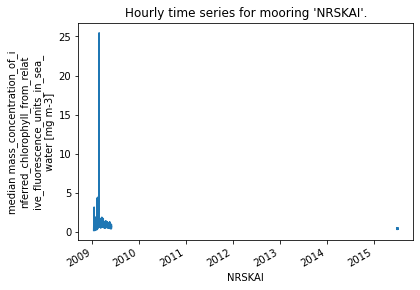

In [22]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc["CHLU"].plot(x="TIME", ax=ax)
ax.set_title(f"Hourly time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

Text(0.5, 0, 'NRSKAI')

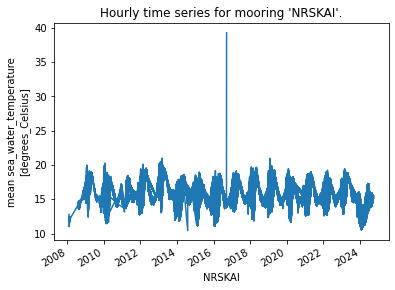

In [23]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc["TEMP"].plot(x="TIME", ax=ax)
ax.set_title(f"Hourly time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

Text(0.5, 0, 'NRSKAI')

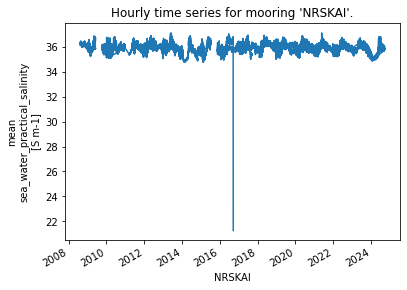

In [25]:
ooring = "NRSKAI"
fig, ax = plt.subplots()
nc["PSAL"].plot(x="TIME", ax=ax)
ax.set_title(f"Hourly time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

Text(0.5, 0, 'NRSKAI')

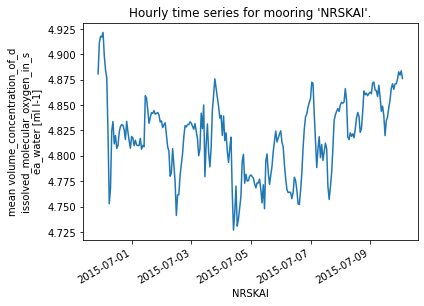

In [26]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc["DOX"].plot(x="TIME", ax=ax)
ax.set_title(f"Hourly time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

### Aggregated time-series

If you are running this for the first time, it might take a while as data is downloaded.

In [31]:
pd.options.display.max_colwidth = 200
fileName = getLTSPfileName(product="aggregated", site="NRSKAI")
print(fileName)

http://thredds.aodn.org.au/thredds/dodsC/IMOS/ANMN/NRS/NRSKAI/aggregated_timeseries/IMOS_ANMN-NRS_TZ_20080212_NRSKAI_FV01_TEMP-aggregated-timeseries_END-20240923_C-20250125.nc


In [32]:
import xarray as xr
import numpy as np

## lets use the fileName discovered above
nc_temp = xr.open_dataset(fileName)

## print the file structure
nc_temp

<xarray.Dataset>
Dimensions:                   (OBSERVATION: 14508127, INSTRUMENT: 586)
Coordinates:
    TIME                      (OBSERVATION) datetime64[ns] ...
    LATITUDE                  (INSTRUMENT) float64 ...
    LONGITUDE                 (INSTRUMENT) float64 ...
    NOMINAL_DEPTH             (INSTRUMENT) float32 ...
Dimensions without coordinates: OBSERVATION, INSTRUMENT
Data variables:
    TEMP                      (OBSERVATION) float32 ...
    TEMP_quality_control      (OBSERVATION) float32 ...
    DEPTH                     (OBSERVATION) float32 ...
    DEPTH_quality_control     (OBSERVATION) float32 ...
    PRES                      (OBSERVATION) float32 ...
    PRES_quality_control      (OBSERVATION) float32 ...
    PRES_REL                  (OBSERVATION) float32 ...
    PRES_REL_quality_control  (OBSERVATION) float32 ...
    instrument_index          (OBSERVATION) int16 ...
    source_file               (INSTRUMENT) |S64 ...
    instrument_id             (INSTRUMENT) |S64 ...
Attributes: (12/41)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      Aggregated Time-series Product: This file ...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Australian Ocean Data Network (AODN)
    author_email:                  info@aodn.org.au
    citation:                      The citation in a list of references is: "...
    ...                            ...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2024-09-23T21:19:59Z
    time_coverage_start:           2008-02-12T07:37:13Z
    title:                         Long Timeseries Velocity Aggregated produc...
    DODS.strlen:                   256
    DODS.dimName:                  strlen

Text(0.5, 0, 'NRSKAI')

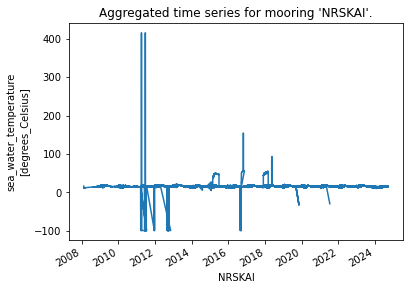

In [33]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc_temp["TEMP"].plot(x="TIME", ax=ax)
ax.set_title(f"Aggregated time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

## PAR

In [34]:
import pandas as pd

pd.options.display.max_colwidth = 500

def getLTSPfileName(site, product="gridded", QC=True, param="PAR", webURL="opendap"):
    '''
    get the url of the LTSP files
    
    require: pandas
    site: the site_code
    product: product type )aggregated, hourly or gridded)
    QC: for the hourly, include only good data (default True)
    param: for aggregated product, parameter code as IMOS standard (e.g. TEMP)
    webURL: web source of the file (S3: Amazon AWS (fastest), wget (AODN THREDDS, to download),
            opendap (AODN THREDDS to open remotely)
    E. Klein. eklein at ocean-analytics dot com dot au
    '''
    
    if webURL == "opendap": 
        WEBROOT = 'http://thredds.aodn.org.au/thredds/dodsC/'
    elif webURL == "wget":
        WEBROOT = 'http://thredds.aodn.org.au/thredds/fileServer/'
    elif webURL == "S3":
        WEBROOT = 'https://s3-ap-southeast-2.amazon.com/imos-data/'
    else:
        print("ERROR: wrong webURL: it must be one of S3, opendap or wget")

  
    urlGeoServer = "http://geoserver-123.aodn.org.au/geoserver/ows?typeName=moorings_all_map&SERVICE=WFS&REQUEST=GetFeature&VERSION=1.0.0&outputFormat=csv&CQL_FILTER=(realtime='FALSE')and(site_code='" + site + "')"
    df = pd.read_csv(urlGeoServer)
    url = df['url']
    
    #fileName = df$url[grepl(paste0(product,"-timeseries"), df$url)]
    fileName = "TEST"
    
    
    if product == "gridded": 
        fileName = url[url.str.contains("gridded")]
    elif product=="velocity-hourly":
        fileName = url[url.str.contains("velocity-hourly")]
    elif product=="hourly":
        if QC:
            fileName = url[url.str.contains("(?<!velocity-)hourly-timeseries(?!-including)", regex=True)]
        else:
            fileName = url[url.str.contains("including-non")]
    elif product=="aggregated":
        fileName = url[url.str.contains(param) & url.str.contains("aggregated")]
    else:
        print("ERROR: invalid combination of arguments or wrong names")

    
    return WEBROOT + fileName.to_string(index=False, header=False).strip()

In [35]:
pd.options.display.max_colwidth = 200
fileName = getLTSPfileName(product="aggregated", site="NRSKAI")
print(fileName)

http://thredds.aodn.org.au/thredds/dodsC/IMOS/ANMN/NRS/NRSKAI/aggregated_timeseries/IMOS_ANMN-NRS_FZ_20150629_NRSKAI_FV01_PAR-aggregated-timeseries_END-20150710_C-20221213.nc


In [37]:
import xarray as xr
import numpy as np

## lets use the fileName discovered above
nc_par = xr.open_dataset(fileName)

## print the file structure
nc_par

<xarray.Dataset>
Dimensions:                   (OBSERVATION: 7379, INSTRUMENT: 1)
Coordinates:
    TIME                      (OBSERVATION) datetime64[ns] ...
    LATITUDE                  (INSTRUMENT) float64 ...
    LONGITUDE                 (INSTRUMENT) float64 ...
    NOMINAL_DEPTH             (INSTRUMENT) float32 ...
Dimensions without coordinates: OBSERVATION, INSTRUMENT
Data variables:
    PAR                       (OBSERVATION) float32 ...
    PAR_quality_control       (OBSERVATION) float32 ...
    DEPTH                     (OBSERVATION) float32 ...
    DEPTH_quality_control     (OBSERVATION) float32 ...
    PRES                      (OBSERVATION) float32 ...
    PRES_quality_control      (OBSERVATION) float32 ...
    PRES_REL                  (OBSERVATION) float32 ...
    PRES_REL_quality_control  (OBSERVATION) float32 ...
    instrument_index          (OBSERVATION) int16 ...
    source_file               (INSTRUMENT) |S64 ...
    instrument_id             (INSTRUMENT) |S64 ...
Attributes: (12/41)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      Aggregated Time-series Product: This file ...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Australian Ocean Data Network (AODN)
    author_email:                  info@aodn.org.au
    citation:                      The citation in a list of references is: "...
    ...                            ...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2015-07-10T02:23:05Z
    time_coverage_start:           2015-06-29T21:22:35Z
    title:                         Long Timeseries Velocity Aggregated produc...
    DODS.strlen:                   256
    DODS.dimName:                  strlen

Text(0.5, 0, 'NRSKAI')

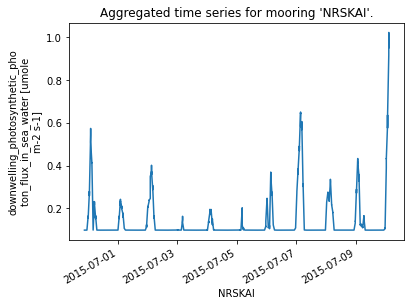

In [40]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc_par["PAR"].plot(x="TIME", ax=ax)
ax.set_title(f"Aggregated time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

## DOX2

In [42]:
import pandas as pd

pd.options.display.max_colwidth = 500

def getLTSPfileName(site, product="gridded", QC=True, param="DOX2", webURL="opendap"):
    '''
    get the url of the LTSP files
    
    require: pandas
    site: the site_code
    product: product type )aggregated, hourly or gridded)
    QC: for the hourly, include only good data (default True)
    param: for aggregated product, parameter code as IMOS standard (e.g. TEMP)
    webURL: web source of the file (S3: Amazon AWS (fastest), wget (AODN THREDDS, to download),
            opendap (AODN THREDDS to open remotely)
    E. Klein. eklein at ocean-analytics dot com dot au
    '''
    
    if webURL == "opendap": 
        WEBROOT = 'http://thredds.aodn.org.au/thredds/dodsC/'
    elif webURL == "wget":
        WEBROOT = 'http://thredds.aodn.org.au/thredds/fileServer/'
    elif webURL == "S3":
        WEBROOT = 'https://s3-ap-southeast-2.amazon.com/imos-data/'
    else:
        print("ERROR: wrong webURL: it must be one of S3, opendap or wget")

  
    urlGeoServer = "http://geoserver-123.aodn.org.au/geoserver/ows?typeName=moorings_all_map&SERVICE=WFS&REQUEST=GetFeature&VERSION=1.0.0&outputFormat=csv&CQL_FILTER=(realtime='FALSE')and(site_code='" + site + "')"
    df = pd.read_csv(urlGeoServer)
    url = df['url']
    
    #fileName = df$url[grepl(paste0(product,"-timeseries"), df$url)]
    fileName = "TEST"
    
    
    if product == "gridded": 
        fileName = url[url.str.contains("gridded")]
    elif product=="velocity-hourly":
        fileName = url[url.str.contains("velocity-hourly")]
    elif product=="hourly":
        if QC:
            fileName = url[url.str.contains("(?<!velocity-)hourly-timeseries(?!-including)", regex=True)]
        else:
            fileName = url[url.str.contains("including-non")]
    elif product=="aggregated":
        fileName = url[url.str.contains(param) & url.str.contains("aggregated")]
    else:
        print("ERROR: invalid combination of arguments or wrong names")

    
    return WEBROOT + fileName.to_string(index=False, header=False).strip()

In [43]:
pd.options.display.max_colwidth = 200
fileName = getLTSPfileName(product="aggregated", site="NRSKAI")
print(fileName)

http://thredds.aodn.org.au/thredds/dodsC/IMOS/ANMN/NRS/NRSKAI/aggregated_timeseries/IMOS_ANMN-NRS_OZ_20090114_NRSKAI_FV01_DOX2-aggregated-timeseries_END-20090601_C-20230412.nc


In [44]:
import xarray as xr
import numpy as np

## lets use the fileName discovered above
nc_dox2 = xr.open_dataset(fileName)

## print the file structure
nc_dox2

<xarray.Dataset>
Dimensions:                   (OBSERVATION: 403913, INSTRUMENT: 1)
Coordinates:
    TIME                      (OBSERVATION) datetime64[ns] ...
    LATITUDE                  (INSTRUMENT) float64 ...
    LONGITUDE                 (INSTRUMENT) float64 ...
    NOMINAL_DEPTH             (INSTRUMENT) float32 ...
Dimensions without coordinates: OBSERVATION, INSTRUMENT
Data variables:
    DOX2                      (OBSERVATION) float32 ...
    DOX2_quality_control      (OBSERVATION) float32 ...
    DEPTH                     (OBSERVATION) float32 ...
    DEPTH_quality_control     (OBSERVATION) float32 ...
    PRES                      (OBSERVATION) float32 ...
    PRES_quality_control      (OBSERVATION) float32 ...
    PRES_REL                  (OBSERVATION) float32 ...
    PRES_REL_quality_control  (OBSERVATION) float32 ...
    instrument_index          (OBSERVATION) int16 ...
    source_file               (INSTRUMENT) |S64 ...
    instrument_id             (INSTRUMENT) |S64 ...
Attributes: (12/41)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      Aggregated Time-series Product: This file ...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Australian Ocean Data Network (AODN)
    author_email:                  info@aodn.org.au
    citation:                      The citation in a list of references is: "...
    ...                            ...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2009-06-01T21:50:39Z
    time_coverage_start:           2009-01-14T23:19:41Z
    title:                         Long Timeseries Velocity Aggregated produc...
    DODS.strlen:                   256
    DODS.dimName:                  strlen

Text(0.5, 0, 'NRSKAI')

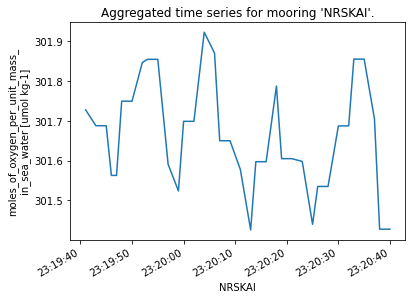

In [45]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc_dox2["DOX2"].plot(x="TIME", ax=ax)
ax.set_title(f"Aggregated time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)

In [41]:
## TURB, CHLU, PSAL, 

In [46]:
import pandas as pd

pd.options.display.max_colwidth = 500

def getLTSPfileName(site, product="gridded", QC=True, param="TURB", webURL="opendap"):
    '''
    get the url of the LTSP files
    
    require: pandas
    site: the site_code
    product: product type )aggregated, hourly or gridded)
    QC: for the hourly, include only good data (default True)
    param: for aggregated product, parameter code as IMOS standard (e.g. TEMP)
    webURL: web source of the file (S3: Amazon AWS (fastest), wget (AODN THREDDS, to download),
            opendap (AODN THREDDS to open remotely)
    E. Klein. eklein at ocean-analytics dot com dot au
    '''
    
    if webURL == "opendap": 
        WEBROOT = 'http://thredds.aodn.org.au/thredds/dodsC/'
    elif webURL == "wget":
        WEBROOT = 'http://thredds.aodn.org.au/thredds/fileServer/'
    elif webURL == "S3":
        WEBROOT = 'https://s3-ap-southeast-2.amazon.com/imos-data/'
    else:
        print("ERROR: wrong webURL: it must be one of S3, opendap or wget")

  
    urlGeoServer = "http://geoserver-123.aodn.org.au/geoserver/ows?typeName=moorings_all_map&SERVICE=WFS&REQUEST=GetFeature&VERSION=1.0.0&outputFormat=csv&CQL_FILTER=(realtime='FALSE')and(site_code='" + site + "')"
    df = pd.read_csv(urlGeoServer)
    url = df['url']
    
    #fileName = df$url[grepl(paste0(product,"-timeseries"), df$url)]
    fileName = "TEST"
    
    
    if product == "gridded": 
        fileName = url[url.str.contains("gridded")]
    elif product=="velocity-hourly":
        fileName = url[url.str.contains("velocity-hourly")]
    elif product=="hourly":
        if QC:
            fileName = url[url.str.contains("(?<!velocity-)hourly-timeseries(?!-including)", regex=True)]
        else:
            fileName = url[url.str.contains("including-non")]
    elif product=="aggregated":
        fileName = url[url.str.contains(param) & url.str.contains("aggregated")]
    else:
        print("ERROR: invalid combination of arguments or wrong names")

    
    return WEBROOT + fileName.to_string(index=False, header=False).strip()

In [47]:
pd.options.display.max_colwidth = 200
fileName = getLTSPfileName(product="aggregated", site="NRSKAI")
print(fileName)

http://thredds.aodn.org.au/thredds/dodsC/IMOS/ANMN/NRS/NRSKAI/aggregated_timeseries/IMOS_ANMN-NRS_UZ_20090114_NRSKAI_FV01_TURB-aggregated-timeseries_END-20150710_C-20221213.nc


In [48]:
import xarray as xr
import numpy as np

## lets use the fileName discovered above
nc_turb = xr.open_dataset(fileName)

## print the file structure
nc_turb

<xarray.Dataset>
Dimensions:                   (OBSERVATION: 411292, INSTRUMENT: 2)
Coordinates:
    TIME                      (OBSERVATION) datetime64[ns] ...
    LATITUDE                  (INSTRUMENT) float64 ...
    LONGITUDE                 (INSTRUMENT) float64 ...
    NOMINAL_DEPTH             (INSTRUMENT) float32 ...
Dimensions without coordinates: OBSERVATION, INSTRUMENT
Data variables:
    TURB                      (OBSERVATION) float32 ...
    TURB_quality_control      (OBSERVATION) float32 ...
    DEPTH                     (OBSERVATION) float32 ...
    DEPTH_quality_control     (OBSERVATION) float32 ...
    PRES                      (OBSERVATION) float32 ...
    PRES_quality_control      (OBSERVATION) float32 ...
    PRES_REL                  (OBSERVATION) float32 ...
    PRES_REL_quality_control  (OBSERVATION) float32 ...
    instrument_index          (OBSERVATION) int16 ...
    source_file               (INSTRUMENT) |S64 ...
    instrument_id             (INSTRUMENT) |S64 ...
Attributes: (12/41)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      Aggregated Time-series Product: This file ...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Australian Ocean Data Network (AODN)
    author_email:                  info@aodn.org.au
    citation:                      The citation in a list of references is: "...
    ...                            ...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2015-07-10T02:23:05Z
    time_coverage_start:           2009-01-14T23:19:41Z
    title:                         Long Timeseries Velocity Aggregated produc...
    DODS.strlen:                   256
    DODS.dimName:                  strlen

Text(0.5, 0, 'NRSKAI')

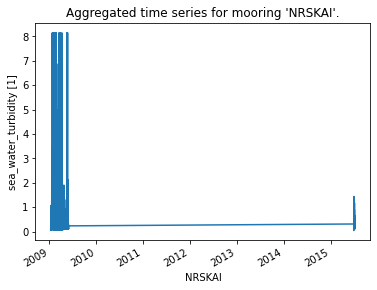

In [50]:
mooring = "NRSKAI"
fig, ax = plt.subplots()
nc_turb["TURB"].plot(x="TIME", ax=ax)
ax.set_title(f"Aggregated time series for mooring '{mooring}'.")
ax.set_xlabel(mooring)